# Start of Baseline and Optimized ANN

## Setting-up

In [1]:
# import os
# os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=0'

# import tensorflow as tf
# tf.config.optimizer.set_jit(False)

In [1]:
!pip install scikeras==0.10.0 scikit-learn==1.5.2 tqdm kagglehub matplotlib seaborn imblearn keras_tuner tensorflow-addons==0.18.0

In [2]:
import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Loading Data

In [3]:
import kagglehub
import pandas as pd
import os

def load_dataset(data_link, file_name, target_column):
  path = kagglehub.dataset_download(data_link)
  full_path = os.path.join(path, file_name)

  try:
      df = pd.read_csv(full_path)
      df = df.rename(columns={target_column: 'target'})
      print("Successfully loaded dataframe.")
  except Exception as e:
      print(f"Failed to load {file_name}: {e}")

  return df

df_train = load_dataset("mohankrishnathalla/sleep-health-and-daily-performance-dataset", "sleep_health_dataset.csv", "felt_rested")
# df_test = load_dataset("kaushiksuresh147/customer-segmentation", "Test.csv", "Segmentation")

c:\Users\nealb\AppData\Local\miniconda3\envs\applied_ml\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 4.07M/4.07M [00:01<00:00, 2.45MB/s]

Extracting files...


Successfully loaded dataframe.


### Initial Data Exploration

#### Showing First 5 Data Points

In [4]:
df_train.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,target
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [5]:
# df_test.head()

#### Identifying DataTypes and Missing Values

In [6]:
print(df_train.info())
# df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

Objects and Missing values are observed, maximum counts are 2627, minimum is 2358.

Raw Counts:
target
0    60988
1    39012
Name: count, dtype: int64

Proportions:
target
0    0.60988
1    0.39012
Name: proportion, dtype: float64


C:\Users\nealb\AppData\Local\Temp\ipykernel_27340\2371519322.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_train, palette='viridis')


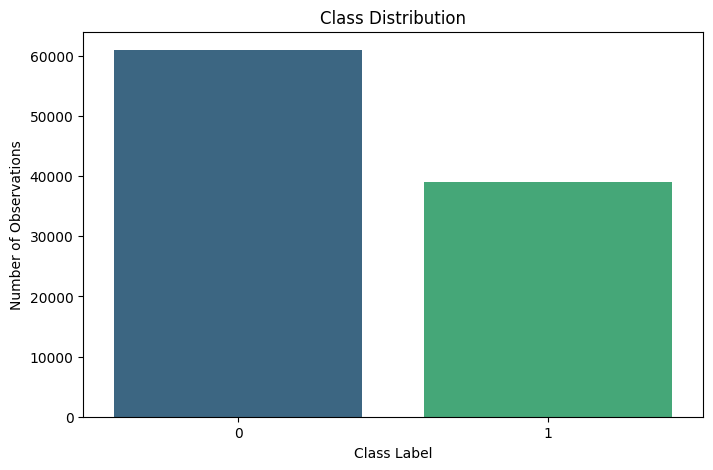

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Statistical Check
print("Raw Counts:")
print(df_train['target'].value_counts())

print("\nProportions:")
print(df_train['target'].value_counts(normalize=True))

# Visualization
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df_train, palette='viridis')
plt.title('Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Number of Observations')
plt.show()

In [8]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Statistical Check
# print("Raw Counts:")
# print(df_test['target'].value_counts())

# print("\nProportions:")
# print(df_test['target'].value_counts(normalize=True))

# # Visualization
# plt.figure(figsize=(8, 5))
# sns.countplot(x='target', data=df_test, palette='viridis')
# plt.title('Class Distribution')
# plt.xlabel('Class Label')
# plt.ylabel('Number of Observations')
# plt.show()

Class imbalance is observed in the dataset for both train and test data.

In [9]:
print(df_train.isna().sum())
# print(df_test.isna().sum())

person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
sleep_diso

In [10]:
df_train.dropna(inplace=True)
# df_test.dropna(inplace=True)
print(df_train.isna().sum())
# print(df_test.isna().sum())

person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
sleep_diso

In [11]:
total_duplicates = df_train.duplicated().sum()
print(f"Total duplicate rows: {total_duplicates}")

Total duplicate rows: 0


In [12]:
# total_duplicates = df_test.duplicated().sum()
# print(f"Total duplicate rows: {total_duplicates}")

No duplicate rows were identified in the dataset.

In [13]:
df_train.drop(columns=["person_id"], inplace=True)
# df_test.drop(columns=["ID"], inplace=True)

The ID column was removed due to unique identifiers not contributing as predictive features for the dataset.

## Data Transformation

#### Nominal and Ordinal Scaling of non-numeric Features

In [14]:
def unique_vals(df, column):
  # Extract an array of unique values
  unique_categories = df[column].unique()
  print("Unique Values Array:")
  print(unique_categories)

In [15]:
unique_vals(df_train, "sleep_disorder_risk")

Unique Values Array:
['Healthy' 'Severe' 'Mild' 'Moderate']


In [16]:
# unique_vals(df_train, "Spending_Score")

In [52]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

# Separate features (X) and target (y) prior to transformations
X = df_train.drop('target', axis=1)
y = df_train['target']

# Define column classifications without overlaps
nominal_cols = [
    'gender',
    'occupation',
    'country',
    'chronotype',
    'mental_health_condition',
    'season',
    'day_type',
]

ordinal_cols = [
    'sleep_disorder_risk'
]

# Define the explicit order for ordinal categories
# These arrays must match the unique values in your actual dataset
# graduated_categories = ['No', 'Yes']
sleep_disorder_risk_categories = ['Healthy', 'Mild', 'Moderate', 'Severe']

# Process nominal features using pandas get_dummies
X_train_encoded = pd.get_dummies(X, columns=nominal_cols)

# Process ordinal features using OrdinalEncoder
ordinal_encoder = OrdinalEncoder(categories=[sleep_disorder_risk_categories])
X_train_encoded[ordinal_cols] = ordinal_encoder.fit_transform(X_train_encoded[ordinal_cols])

# Process the target variable using LabelEncoder
# This encodes the target as integers for sparse_categorical_crossentropy loss
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y)

# Verify the final data types and structure
print(X_train_encoded.info())
print(f"Target shape: {X_train_encoded.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 66 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   bmi                                 100000 non-null  float64
 2   sleep_duration_hrs                  100000 non-null  float64
 3   sleep_quality_score                 100000 non-null  float64
 4   rem_percentage                      100000 non-null  float64
 5   deep_sleep_percentage               100000 non-null  float64
 6   sleep_latency_mins                  100000 non-null  int64  
 7   wake_episodes_per_night             100000 non-null  int64  
 8   caffeine_mg_before_bed              100000 non-null  int64  
 9   alcohol_units_before_bed            100000 non-null  float64
 10  screen_time_before_bed_mins         100000 non-null  int64  
 11  exercise_day               

In [53]:
y_train_encoded

array([0, 1, 0, ..., 1, 0, 0], dtype=int64)

In [54]:
# # Separate features (X) and target (y) prior to transformations
# X = df_test.drop('target', axis=1)
# y = df_test['target']

# # Process nominal features using pandas get_dummies
# X_test_encoded = pd.get_dummies(X, columns=nominal_cols)

# # Process ordinal features using OrdinalEncoder
# # ordinal_encoder = OrdinalEncoder(categories=[graduated_categories, spending_categories])
# X_test_encoded[ordinal_cols] = ordinal_encoder.fit_transform(X_test_encoded[ordinal_cols])

# # Process the target variable using LabelEncoder
# # This encodes the target as integers for sparse_categorical_crossentropy loss
# # label_encoder = LabelEncoder()
# y_test_encoded = label_encoder.fit_transform(y)

# # Verify the final data types and structure
# print(X_test_encoded.info())
# print(f"Target shape: {X_test_encoded.shape}")

The columns of the dataset were transformed depending on their nominal or ordinal nature. Among the data, only Graduated and Spendinc_Score were treated as ordinal data, while the rest of dtype "Object" were transform using Ordinal encoder of scikit-learn.

### Exploring Feature Correlation

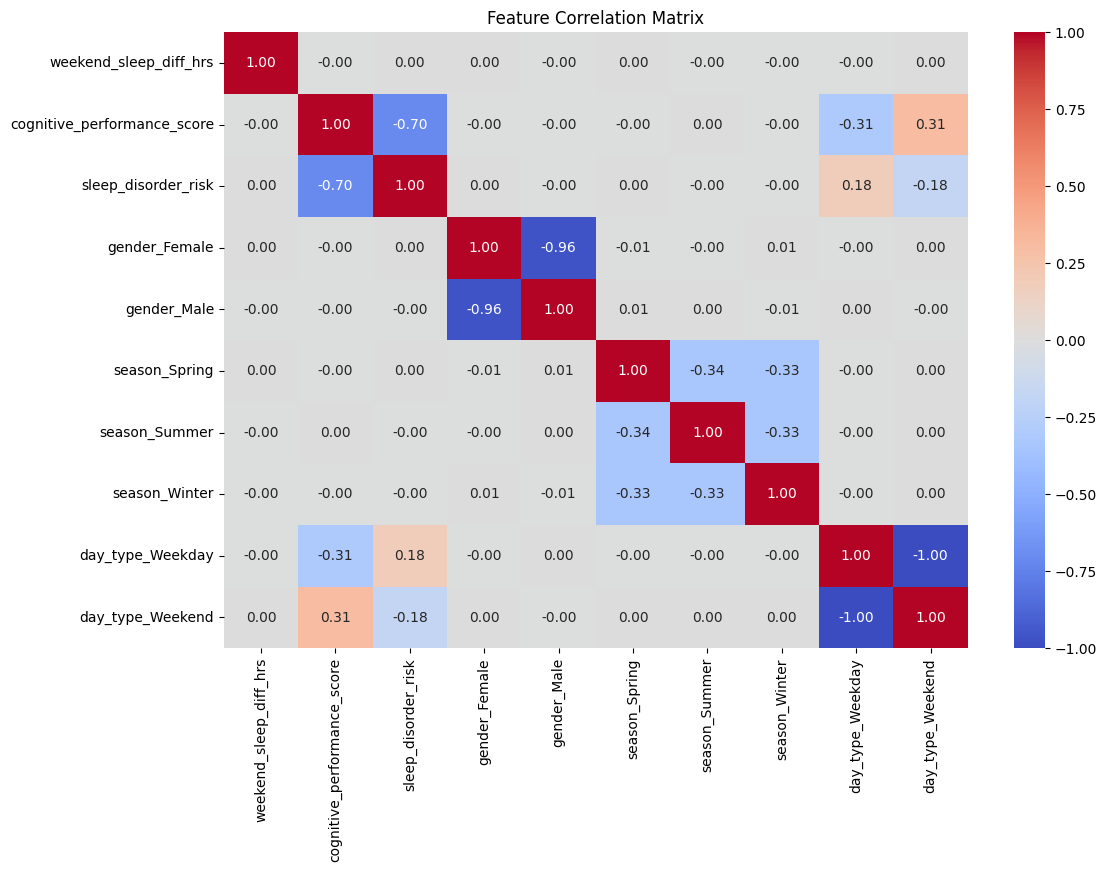

In [71]:
# Select the first 10 and last 10 columns
selected_columns = list(X_train_encoded.columns[20:25]) + list(X_train_encoded.columns[-5:])

# Correlation matrix to assess feature redundancy
plt.figure(figsize=(12,8))
correlation_matrix = X_train_encoded[selected_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

In [21]:
import numpy as np
# Calculate the absolute correlation matrix
corr_matrix_abs = correlation_matrix.abs()

# Select the upper triangle of the correlation matrix
upper_triangle = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

# Find features with correlation greater than 0.95
correlation_threshold = 0.95
features_to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > correlation_threshold)]

print(f"Features dropped due to high correlation (> {correlation_threshold}): \n{features_to_drop}")

# Drop the highly correlated features
X_train_encoded = X_train_encoded.drop(columns=features_to_drop)
# X_test_encoded = X_test_encoded.drop(columns=features_to_drop)

Features dropped due to high correlation (> 0.95): 
['gender_Male', 'day_type_Weekend']


### Statistical Check

In [22]:
import pandas as pd

# Select only numerical features to avoid calculating stats on boolean columns
num_cols = X_train_encoded.select_dtypes(include=['float64'])

# Generate standard descriptive statistics
descriptive_stats = num_cols.describe()

# Calculate and append skewness and kurtosis
descriptive_stats.loc['skewness'] = num_cols.skew()
descriptive_stats.loc['kurtosis'] = num_cols.kurtosis()

# Display the final summary table
print(descriptive_stats)

                    bmi  sleep_duration_hrs  sleep_quality_score  \
count     100000.000000       100000.000000        100000.000000   
mean          26.289673            6.423986             4.871144   
std            4.479578            1.274627             1.506517   
min           16.000000            3.000000             1.000000   
25%           23.200000            5.530000             3.800000   
50%           26.300000            6.360000             4.900000   
75%           29.300000            7.270000             6.000000   
max           45.000000           10.500000            10.000000   
skewness       0.071914            0.216783            -0.091709   
kurtosis      -0.180689           -0.078708            -0.419022   

          rem_percentage  deep_sleep_percentage  alcohol_units_before_bed  \
count      100000.000000          100000.000000             100000.000000   
mean           20.243968              20.253375                  0.596800   
std             3.41

### Checking continuous features for skewness

In [23]:
print(X_train_encoded.head())

   age   bmi  sleep_duration_hrs  sleep_quality_score  rem_percentage  \
0   29  25.7                6.19                  6.6            22.5   
1   55  22.0                8.32                  6.9            26.9   
2   42  25.0                3.74                  1.0            20.2   
3   37  29.5                6.79                  6.4            17.7   
4   23  23.6                5.02                  3.2            23.3   

   deep_sleep_percentage  sleep_latency_mins  wake_episodes_per_night  \
0                   19.3                  16                        3   
1                   14.9                  17                        4   
2                   16.2                  26                        4   
3                   17.7                  13                        4   
4                   18.3                  30                        5   

   caffeine_mg_before_bed  alcohol_units_before_bed  ...  chronotype_Neutral  \
0                       0                 

Continuous Feature Skewness:
caffeine_mg_before_bed         2.384080
alcohol_units_before_bed       1.927083
sleep_disorder_risk            1.255640
nap_duration_mins              1.205569
screen_time_before_bed_mins    1.152855
age                            0.549902
wake_episodes_per_night        0.454924
sleep_latency_mins             0.242292
sleep_duration_hrs             0.216783
steps_that_day                 0.135000
room_temperature_celsius       0.128792
bmi                            0.071914
heart_rate_resting_bpm         0.005647
weekend_sleep_diff_hrs        -0.052748
sleep_quality_score           -0.091709
deep_sleep_percentage         -0.108602
rem_percentage                -0.113301
work_hours_that_day           -0.161502
cognitive_performance_score   -0.289882
stress_score                  -0.363788
dtype: float64


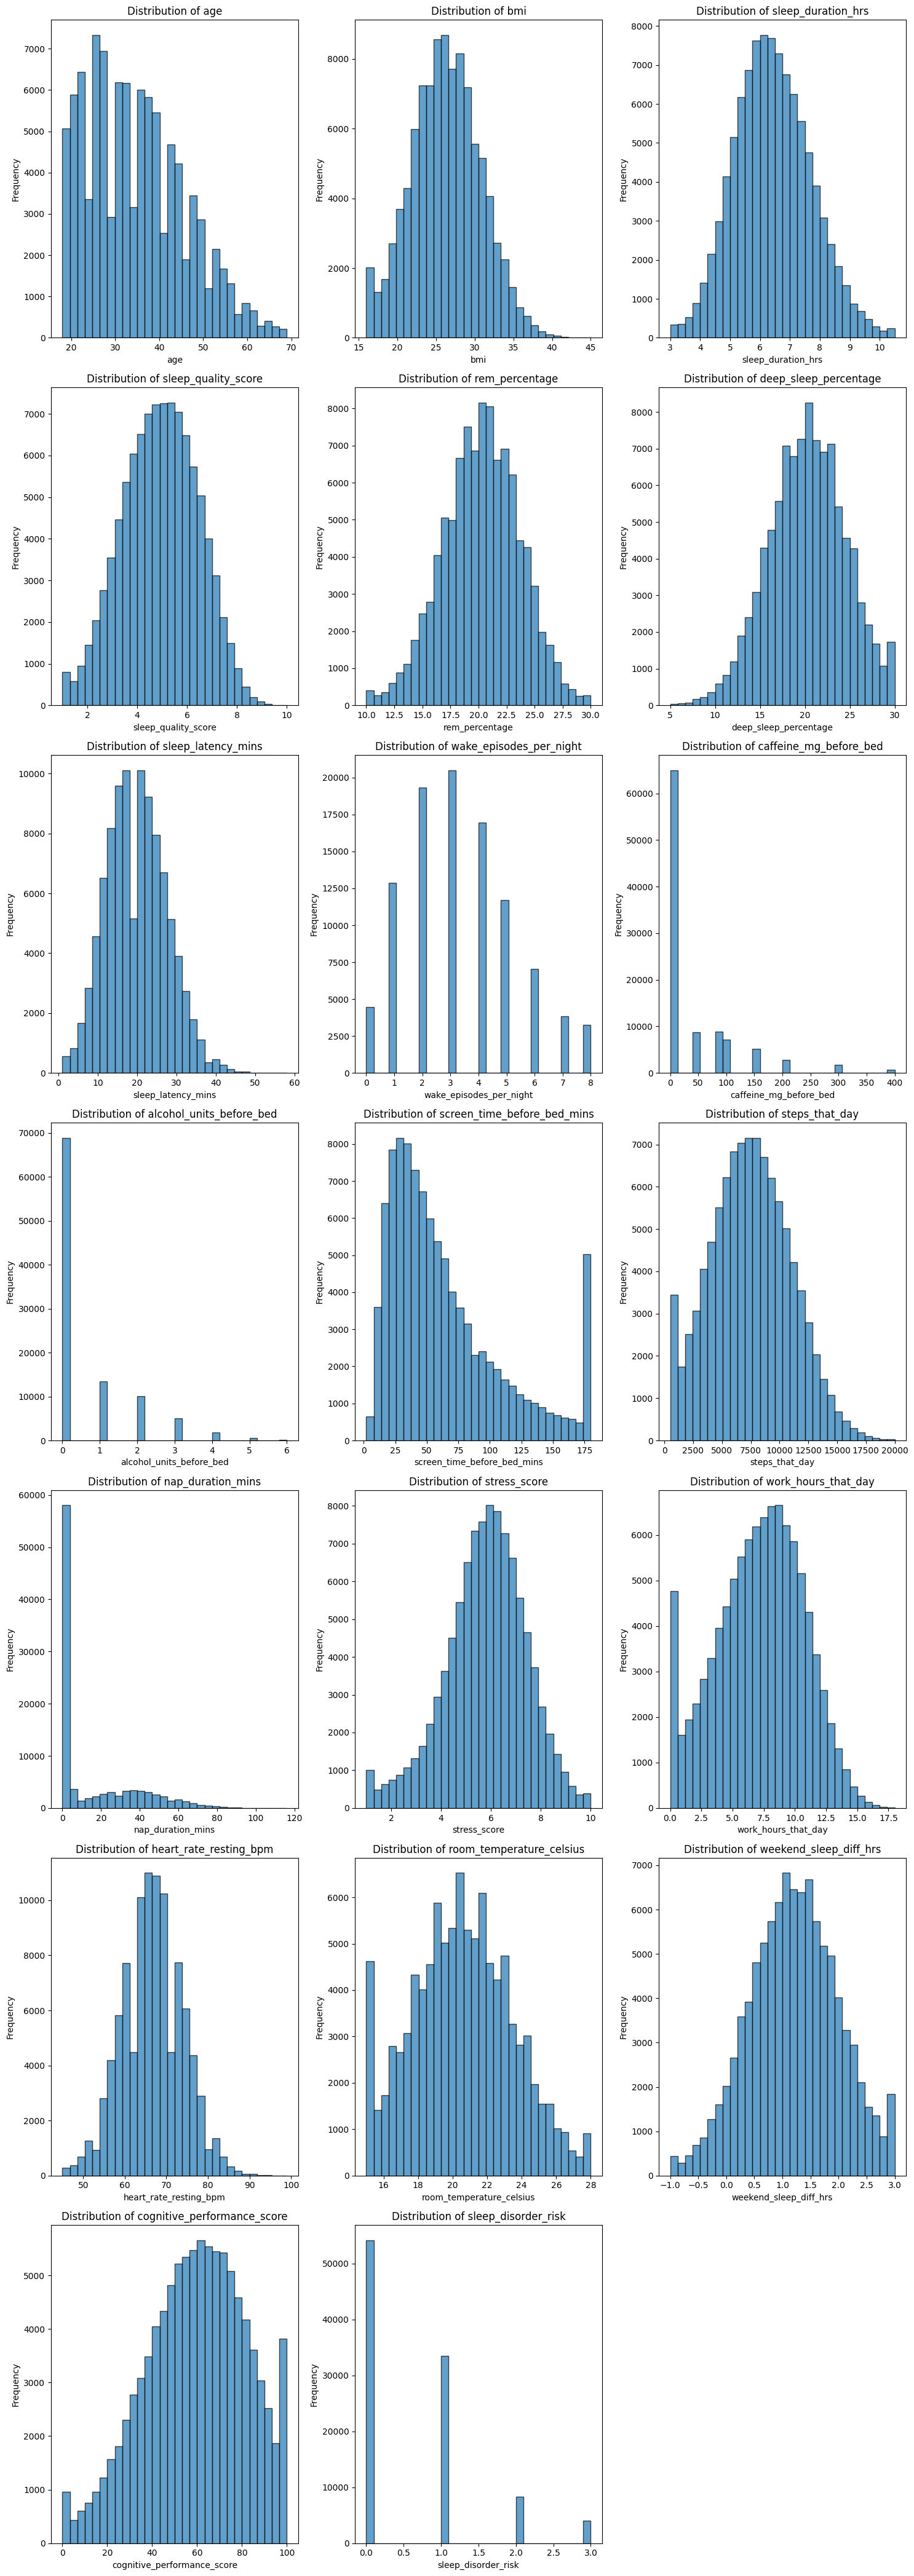

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Identify numeric columns dynamically
# A threshold for unique values helps distinguish continuous variables 
# from discrete features that may also be represented by numeric types.
unique_threshold = 2
continuous_cols = [
    col for col in X_train_encoded.select_dtypes(include=[np.number, np.float64, np.int64]).columns 
    if X_train_encoded[col].nunique() > unique_threshold
]

# Assess Skewness on Continuous Variables Only
continuous_skewness = X_train_encoded[continuous_cols].skew().sort_values(ascending=False)

print("Continuous Feature Skewness:")
print(continuous_skewness)

# Calculate grid size dynamically to accommodate the identified columns
num_plots = len(continuous_cols)
ncols = 3
nrows = (num_plots + ncols - 1) // ncols

# Create a grid of subplots for the distributions
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 6 * nrows))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Ensure axes is an iterable array even if only one plot exists
if num_plots > 1:
    axes = axes.ravel()
else:
    axes = np.array([axes])

# Plot a histogram for each continuous variable
for i, col in enumerate(continuous_cols):
    # Drop NA values to prevent matplotlib errors during rendering
    axes[i].hist(X_train_encoded[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots in the grid
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()

# Save the figure or display it depending on your environment
plt.savefig("continuous_distributions.png")
plt.show()

In [25]:
from sklearn.model_selection import train_test_split

X = X_train_encoded
y = y_train_encoded

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 64000 samples
Validation set size: 16000 samples
Test set size: 20000 samples


In [26]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, MinMaxScaler, RobustScaler, StandardScaler

# Update columns to address the observed right skews
skewed_cols = ['age']

outlier_heavy_cols = ['nap_duration_mins', 'screen_time_before_bed_mins']

standard_cols = ['bmi', 'sleep_quality_score', 'sleep_quality_score',
                 'rem_percentage','deep_sleep_percentage','sleep_latency_mins',
                 'steps_that_day','stress_score','work_hours_that_day',
                 'heart_rate_resting_bpm','room_temperature_celsius',
                 'weekend_sleep_diff_hrs','cognitive_performance_score']

minmax_cols = ['caffeine_mg_before_bed', 'alcohol_units_before_bed' ,
               'sleep_disorder_risk', 'wake_episodes_per_night']

preprocessor = ColumnTransformer(
    transformers=[
        ('power', PowerTransformer(method='yeo-johnson'), skewed_cols),
        ('robust', RobustScaler(), outlier_heavy_cols),
        ('standard', StandardScaler(), standard_cols),
        ('minmax', StandardScaler(), minmax_cols)
    ],
    remainder='passthrough'
)

# Fit and transform the datasets
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Explicitly cast the resulting object arrays to float32 for TensorFlow
X_train_scaled = np.asarray(X_train_scaled).astype(np.float32)
X_test_scaled = np.asarray(X_test_scaled).astype(np.float32)

# Verify the final data type
print(f"X_train_scaled dtype: {X_train_scaled.dtype}")

X_train_scaled dtype: float32


Age was handled as a skewed column and transformed using yeo-johnson, while spending score and familiy size was transformed using min max. The rest of the columns just pass through as they are already binari encoded (one-hot)

## Exploring and Handling Class Imblance using SMOTE

In [27]:
import pandas as pd
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE strictly to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Verify the class distribution before and after SMOTE
print("Original Training Target Distribution:")
print(pd.Series(y_train).value_counts())

print("\n" + "="*40 + "\n")

print("SMOTE Training Target Distribution:")
print(pd.Series(y_train_resampled).value_counts())

Original Training Target Distribution:
0    39135
1    24865
Name: count, dtype: int64


SMOTE Training Target Distribution:
1    39135
0    39135
Name: count, dtype: int64


The training data class imbalance was handled with a number of 1387 datapoints now for each class.

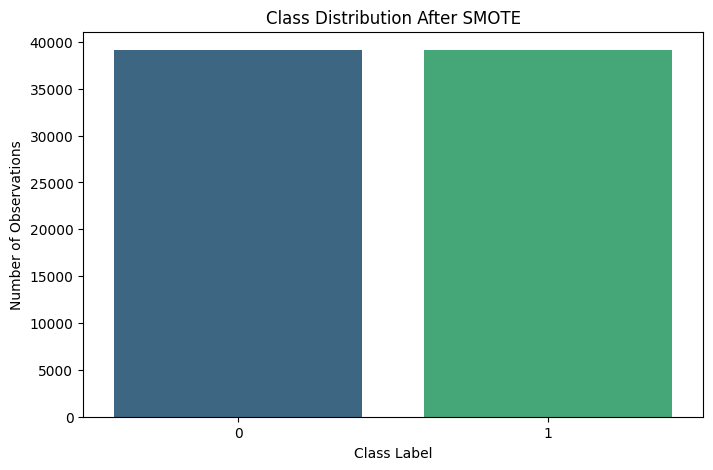

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame and explicitly name the column
df_resampled = pd.DataFrame(y_train_resampled, columns=['target'])

# Visualization
plt.figure(figsize=(8, 5))

# Use the string column name for both x and hue to safely apply the palette
sns.countplot(data=df_resampled, x='target', hue='target', palette='viridis', legend=False)

plt.title('Class Distribution After SMOTE')
plt.xlabel('Class Label')
plt.ylabel('Number of Observations')
plt.show()

In [29]:
y_train_resampled[:10]

array([1, 0, 0, 1, 0, 1, 1, 1, 0, 0], dtype=int64)

## Build a Baseline ANN Model

Creating baseline ANN model based on

In [31]:
import tensorflow as tf

# Verify GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable memory growth so TF only takes what it needs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU detected: {gpus}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU detected. Check your CUDA/cuDNN installation.")
    

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [32]:
import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [33]:
import tensorflow as tf

# Check if TensorFlow is linked to CUDA
print("Built with CUDA:", tf.test.is_built_with_cuda())

# Check GPU details and recognized CUDA version
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    # This specifically checks the version linked to the binary
    from tensorflow.python.platform import build_info as tf_build_info
    print("TF CUDA Version:", tf_build_info.build_info['cuda_version'])
    print("TF cuDNN Version:", tf_build_info.build_info['cudnn_version'])
else:
    print("No GPU detected by TensorFlow.")

Built with CUDA: True
TF CUDA Version: 64_112
TF cuDNN Version: 64_8


In [39]:
# Convert features to float32 for model weights
X_train_resampled = np.array(X_train_resampled).astype('float32')
X_val = np.array(X_val).astype('float32')
X_test = np.array(X_test).astype('float32')

# Convert labels to int32 
y_train_resampled = np.array(y_train_resampled).astype('int32')
y_val = np.array(y_val).astype('int32')
y_test = np.array(y_test).astype('int32')

### Baseline Model Training

In [35]:
import numpy as np
from keras.models import Model
from keras.layers import Input, Dense

# Determine dynamic shapes directly from the resampled data
input_dim = X_train_resampled.shape[1]
num_classes = len(np.unique(y_train_resampled))

# Defining the ANN
input_layer = Input(shape=(input_dim,), name='input_1')

# Dense Layers
x = Dense(32, activation='relu', name='dense_1')(input_layer)
x = Dense(32, activation='relu', name='dense_2')(x)

# Output layer configured for multi-class classification
output_layer = Dense(num_classes, activation='softmax', name='output_1')(x)

# Compiling the model
model = Model(inputs=input_layer, outputs=output_layer, name='baseline_model')
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Displaying the model parameters
model.summary()

Model: "baseline_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64)]              0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 32)                1056      
                                                                 
 output_1 (Dense)            (None, 2)                 66        
                                                                 
Total params: 3,202
Trainable params: 3,202
Non-trainable params: 0
_________________________________________________________________


In [36]:
## Training/Fitting the model
baseline_history = model.fit(X_train_resampled, y_train_resampled,
                    validation_data=(X_val, y_val), epochs=32)

Epoch 1/32
2446/2446 [==============================] - 11s 3ms/step - loss: 4.1307 - accuracy: 0.6298 - val_loss: 2.0825 - val_accuracy: 0.6670
Epoch 2/32
2446/2446 [==============================] - 8s 3ms/step - loss: 2.5403 - accuracy: 0.6672 - val_loss: 2.2719 - val_accuracy: 0.6655
Epoch 3/32
2446/2446 [==============================] - 9s 4ms/step - loss: 2.3650 - accuracy: 0.6779 - val_loss: 3.0031 - val_accuracy: 0.6412
Epoch 4/32
2446/2446 [==============================] - 9s 3ms/step - loss: 1.7543 - accuracy: 0.6944 - val_loss: 5.1300 - val_accuracy: 0.6197
Epoch 5/32
2446/2446 [==============================] - 8s 3ms/step - loss: 1.6265 - accuracy: 0.6988 - val_loss: 3.2268 - val_accuracy: 0.5300
Epoch 6/32
2446/2446 [==============================] - 8s 3ms/step - loss: 1.5200 - accuracy: 0.7008 - val_loss: 0.7144 - val_accuracy: 0.7327
Epoch 7/32
2446/2446 [==============================] - 8s 3ms/step - loss: 1.2626 - accuracy: 0.7062 - val_loss: 0.6496 - val_accuracy

In [34]:
# @title Function for Multi Class Evaluation
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

def plot_training_history(history_obj):
    """
    Plots the training and validation loss and accuracy per epoch.
    Accepts either a Keras History object or a history dictionary.
    """
    # Extract the dictionary if a Keras History object is passed
    history_dict = history_obj.history if hasattr(history_obj, 'history') else history_obj

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss Plot
    axes[0].plot(history_dict['loss'], label='Train Loss', color='blue', linewidth=2)
    if 'val_loss' in history_dict:
        axes[0].plot(history_dict['val_loss'], label='Validation Loss', color='orange', linewidth=2)
    axes[0].set_title('Model Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Accuracy Plot
    axes[1].plot(history_dict['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
    if 'val_accuracy' in history_dict:
        axes[1].plot(history_dict['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
    axes[1].set_title('Model Accuracy per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend(loc='lower right')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

def evaluate_multiclass_model(model, X_set, y_set, n_classes, scikeras=False):
    """
    Evaluates a trained binary or multi-class ANN model and prints performance metrics.
    Generates a Confusion Matrix and a relevant ROC Curve.
    Returns a dictionary containing the numeric evaluation metrics.
    """
    # Inside your evaluate_multiclass_model function:
    if scikeras:
        y_prob = model.predict_proba(X_set)
    else:
        # Native Keras models return probabilities via .predict()
        y_prob = model.predict(X_set)

    # Determine predicted classes based on output shape
    if y_prob.ndim == 1 or y_prob.shape[1] == 1:
        # Binary sigmoid case: shape is (N,) or (N, 1)
        y_prob_clean = y_prob.flatten()
        y_pred = (y_prob_clean >= 0.5).astype(int)
    else:
        # Multi-class softmax case: shape is (N, n_classes)
        y_pred = np.argmax(y_prob, axis=1)
        y_prob_clean = y_prob

    # Calculate metrics using macro average for consistent support
    accuracy = accuracy_score(y_set, y_pred)
    precision = precision_score(y_set, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_set, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_set, y_pred, average='macro', zero_division=0)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision (Macro): {precision:.4f}")
    print(f"Recall (Macro):    {recall:.4f}")
    print(f"F1-score (Macro):  {f1:.4f}\n")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_set, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # ROC Curve and AUC Logic
    if n_classes == 2:
        # Binary case: label_binarize returns (N, 1), so we use y_set directly
        # Use probabilities of the positive class
        pos_prob = y_prob_clean[:, 1] if y_prob_clean.ndim > 1 else y_prob_clean
        fpr, tpr, _ = roc_curve(y_set, pos_prob)
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, lw=2, label=f'Binary ROC (AUC = {roc_auc:.2f})')
    else:
        # Multi-class One-vs-Rest approach
        y_set_binarized = label_binarize(y_set, classes=range(n_classes))
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_set_binarized[:, i], y_prob_clean[:, i])
            roc_auc = auc(fpr, tpr)
            axes[1].plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Receiver Operating Characteristic')
    axes[1].legend(loc="lower right", fontsize='small')

    plt.tight_layout()
    plt.show()

    # Return the metrics in a pandas DataFrame
    df = pd.DataFrame([{
        'Accuracy': accuracy,
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1-score (Macro)': f1
    }])
    return df

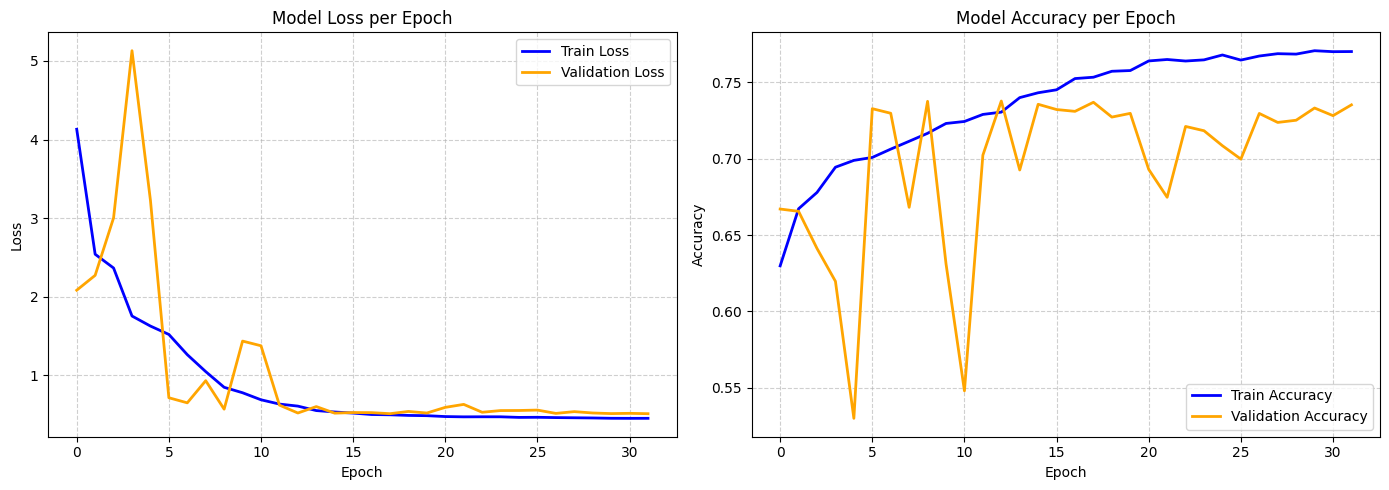

In [38]:
plot_training_history(baseline_history)

625/625 [==============================] - 1s 1ms/step
Accuracy:  0.7333
Precision (Macro): 0.7218
Recall (Macro):    0.7090
F1-score (Macro):  0.7132



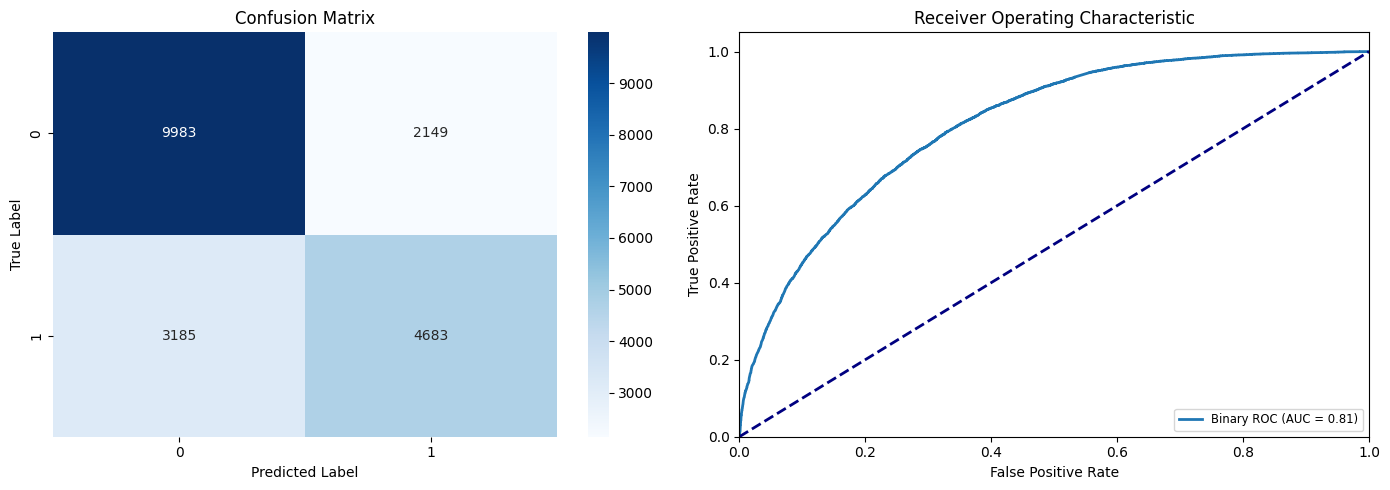

In [39]:
baseline_metrics = evaluate_multiclass_model(model, X_test, y_test, 2)

#### Saving Baseline Results

In [40]:
# Save Training History to CSV
history_df = pd.DataFrame(baseline_history.history)
history_df.to_csv('baseline_training_history.csv', index_label='epoch')

# Save Evaluation Metrics to CSV
baseline_metrics.to_csv('baseline_model_metrics.csv', index=False)

### Optimized Model Training

In [41]:
# import numpy as np
# import pandas as pd
# import joblib
# import contextlib
# from tqdm import tqdm
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import loguniform, randint
# from scikeras.wrappers import KerasClassifier
# from tensorflow.keras.models import Model
# from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Nadam, AdamW
# from tensorflow.keras.losses import SparseCategoricalCrossentropy
# from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, LeakyReLU
# from tensorflow.keras.callbacks import EarlyStopping

# # Context manager to patch joblib and report progress to tqdm
# @contextlib.contextmanager
# def tqdm_joblib(tqdm_object):
#     class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
#         def __call__(self, *args, **kwargs):
#             tqdm_object.update(n=self.batch_size)
#             return super().__call__(*args, **kwargs)

#     old_batch_callback = joblib.parallel.BatchCompletionCallBack
#     joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
#     try:
#         yield tqdm_object
#     finally:
#         joblib.parallel.BatchCompletionCallBack = old_batch_callback

# def create_model(num_layers=1, units=32, activation_func='relu',
#                  optimizer_name='adam', learning_rate=0.001, n_classes=4):
#     input_layer = Input(shape=(X_train_resampled.shape[1],), name="input_1")
#     x = input_layer

#     for i in range(num_layers):
#         if activation_func == 'leaky_relu':
#             x = Dense(units, name=f"dense_{i+1}")(x)
#             x = LeakyReLU(alpha=0.01, name=f"leaky_relu_{i+1}")(x)
#         else:
#             x = Dense(units, activation=activation_func, name=f"dense_{i+1}")(x)

#         x = BatchNormalization(name=f"batch_norm_{i+1}")(x)
#         x = Dropout(0.2, name=f"dropout_{i+1}")(x)

#     output_layer = Dense(n_classes, activation='softmax', name="output_1")(x)
#     model = Model(inputs=input_layer, outputs=output_layer, name="optimized_classifier")

#     optimizers = {
#         'adam': Adam(learning_rate=learning_rate),
#         'sgd': SGD(learning_rate=learning_rate),
#         'rmsprop': RMSprop(learning_rate=learning_rate),
#         'adamw': AdamW(learning_rate=learning_rate),
#         'nadam': Nadam(learning_rate=learning_rate)
#     }

#     opt = optimizers.get(optimizer_name, Adam(learning_rate=learning_rate))

#     model.compile(
#         optimizer=opt,
#         loss=SparseCategoricalCrossentropy(),
#         metrics=['accuracy']
#     )
#     return model

# early_stopping = EarlyStopping(
#     monitor='val_loss',
#     patience=15,
#     restore_best_weights=True
# )

# keras_estimator = KerasClassifier(
#     model=create_model,
#     model__n_classes=4,
#     verbose=0,
#     callbacks=[early_stopping],
# )

# param_distributions = {
#     'model__num_layers': randint(1, 6),
#     'model__units': [32, 64, 128, 256, 512],
#     'model__activation_func': ['relu', 'tanh', 'leaky_relu', 'elu'],
#     'model__optimizer_name': ['adam', 'adamw', 'nadam'],
#     'model__learning_rate': loguniform(1e-4, 1e-2),
#     'batch_size': [32, 64, 128, 256, 512, 1024],
#     'epochs': [32, 64, 128, 256,512]
# }

# n_iter = 50
# cv = 3
# random_search = RandomizedSearchCV(
#     estimator=keras_estimator,
#     param_distributions=param_distributions,
#     n_iter=n_iter,
#     cv=cv,
#     scoring='accuracy',
#     n_jobs=8,
#     random_state=42
# )

# print("Starting randomized search for classification...")
# # Calculate total fits: n_iter * cv
# with tqdm_joblib(tqdm(desc="RandomSearch", total=n_iter * cv)) as progress_bar:
#     search_result = random_search.fit(
#         X_train_resampled,
#         y_train_resampled,
#         validation_data=(X_val, y_val)
#     )

# final_model = search_result.best_estimator_
# print(f"\nBest F1 Score: {search_result.best_score_:.4f}")
# print(f"Best Parameters: {search_result.best_params_}")

In [30]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_addons as tfa
import keras_tuner as kt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam, RMSprop, Nadam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, CSVLogger

# 1. Hardware and Data Setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

X_train_resampled = X_train_resampled.astype('float32')
y_train_resampled = y_train_resampled.astype('int32')
X_val = X_val.astype('float32')
y_val = y_val.astype('int32')
num_classes = len(np.unique(y_train_resampled))

class MyBayesianTuner(kt.BayesianOptimization):
    def run_trial(self, trial, x, y, validation_data, **kwargs):
        hp = trial.hyperparameters
        batch_size = hp.Choice('batch_size', [32, 64, 128, 256, 512, 1024])
        
        # Create a directory for this specific trial's logs
        trial_dir = os.path.join(self.directory, self.project_name, f"trial_{trial.trial_id}")
        os.makedirs(trial_dir, exist_ok=True)
        
        # Define a CSVLogger for this trial
        history_file = os.path.join(trial_dir, "trial_history.csv")
        csv_logger = CSVLogger(history_file)
        
        # Create a clean copy of the callbacks list to prevent accumulation
        trial_callbacks = kwargs.get('callbacks', []).copy()
        trial_callbacks.append(csv_logger)
        kwargs['callbacks'] = trial_callbacks
        
        # Prepare datasets
        train_ds = tf.data.Dataset.from_tensor_slices((x, y))
        train_ds = (train_ds.shuffle(10000)
                    .batch(batch_size)
                    .cache()
                    .prefetch(tf.data.AUTOTUNE))
        
        val_x, val_y = validation_data
        val_ds = (tf.data.Dataset.from_tensor_slices((val_x, val_y))
                  .batch(batch_size)
                  .cache()
                  .prefetch(tf.data.AUTOTUNE))
        
        # Run the trial
        return super(MyBayesianTuner, self).run_trial(
            trial, train_ds, validation_data=val_ds, **kwargs
        )

# 3. Enhanced Model Builder
def build_model(hp):
    input_layer = Input(shape=(X_train_resampled.shape[1],), name="input_1")
    x = input_layer

    num_layers = hp.Int('num_layers', 1, 5)
    activation_func = hp.Choice('activation_func', ['relu', 'leaky_relu', 'elu'])
    dropout_rate = hp.Float('dropout_rate', 0.0, 0.4, step=0.1)
    batchnorm = hp.Boolean('batchnorm')

    for i in range(num_layers):
        units = hp.Choice(f'units_l{i}', [32, 64, 128, 256, 512])
        
        if activation_func == 'leaky_relu':
            x = Dense(units, name=f"dense_{i+1}")(x)
            x = LeakyReLU(alpha=0.01, name=f"leaky_relu_{i+1}")(x)
        else:
            x = Dense(units, activation=activation_func, name=f"dense_{i+1}")(x)

        if batchnorm:
            x = BatchNormalization(name=f"batch_norm_{i+1}")(x)
        x = Dropout(dropout_rate, name=f"dropout_{i+1}")(x)

    output_layer = Dense(num_classes, activation='softmax', name="output_1")(x)
    model = Model(inputs=input_layer, outputs=output_layer)

    learning_rate = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    optimizer_name = hp.Choice('optimizer_name', ['adam', 'rmsprop', 'adamw', 'nadam'])

    if optimizer_name == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer_name == 'adamw':
        wd = hp.Float('weight_decay', 1e-5, 1e-3, sampling='log')
        opt = tfa.optimizers.AdamW(weight_decay=wd, learning_rate=learning_rate)
    elif optimizer_name == 'nadam':
        opt = Nadam(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 4. Search Execution
tuner = MyBayesianTuner(
    build_model,
    objective='val_loss', 
    max_trials=50,
    directory='bayesian_tuning_v4',
    project_name='customer_seg_final',
    overwrite=False
)

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=5, 
    min_lr=1e-8
)

print("Starting final Bayesian Optimization...")
tuner.search(
    x=X_train_resampled,
    y=y_train_resampled,
    validation_data=(X_val, y_val),
    epochs=512,
    callbacks=[early_stopping, reduce_lr]
)

Reloading Tuner from bayesian_tuning_v4\customer_seg_final\tuner0.json
Starting final Bayesian Optimization...


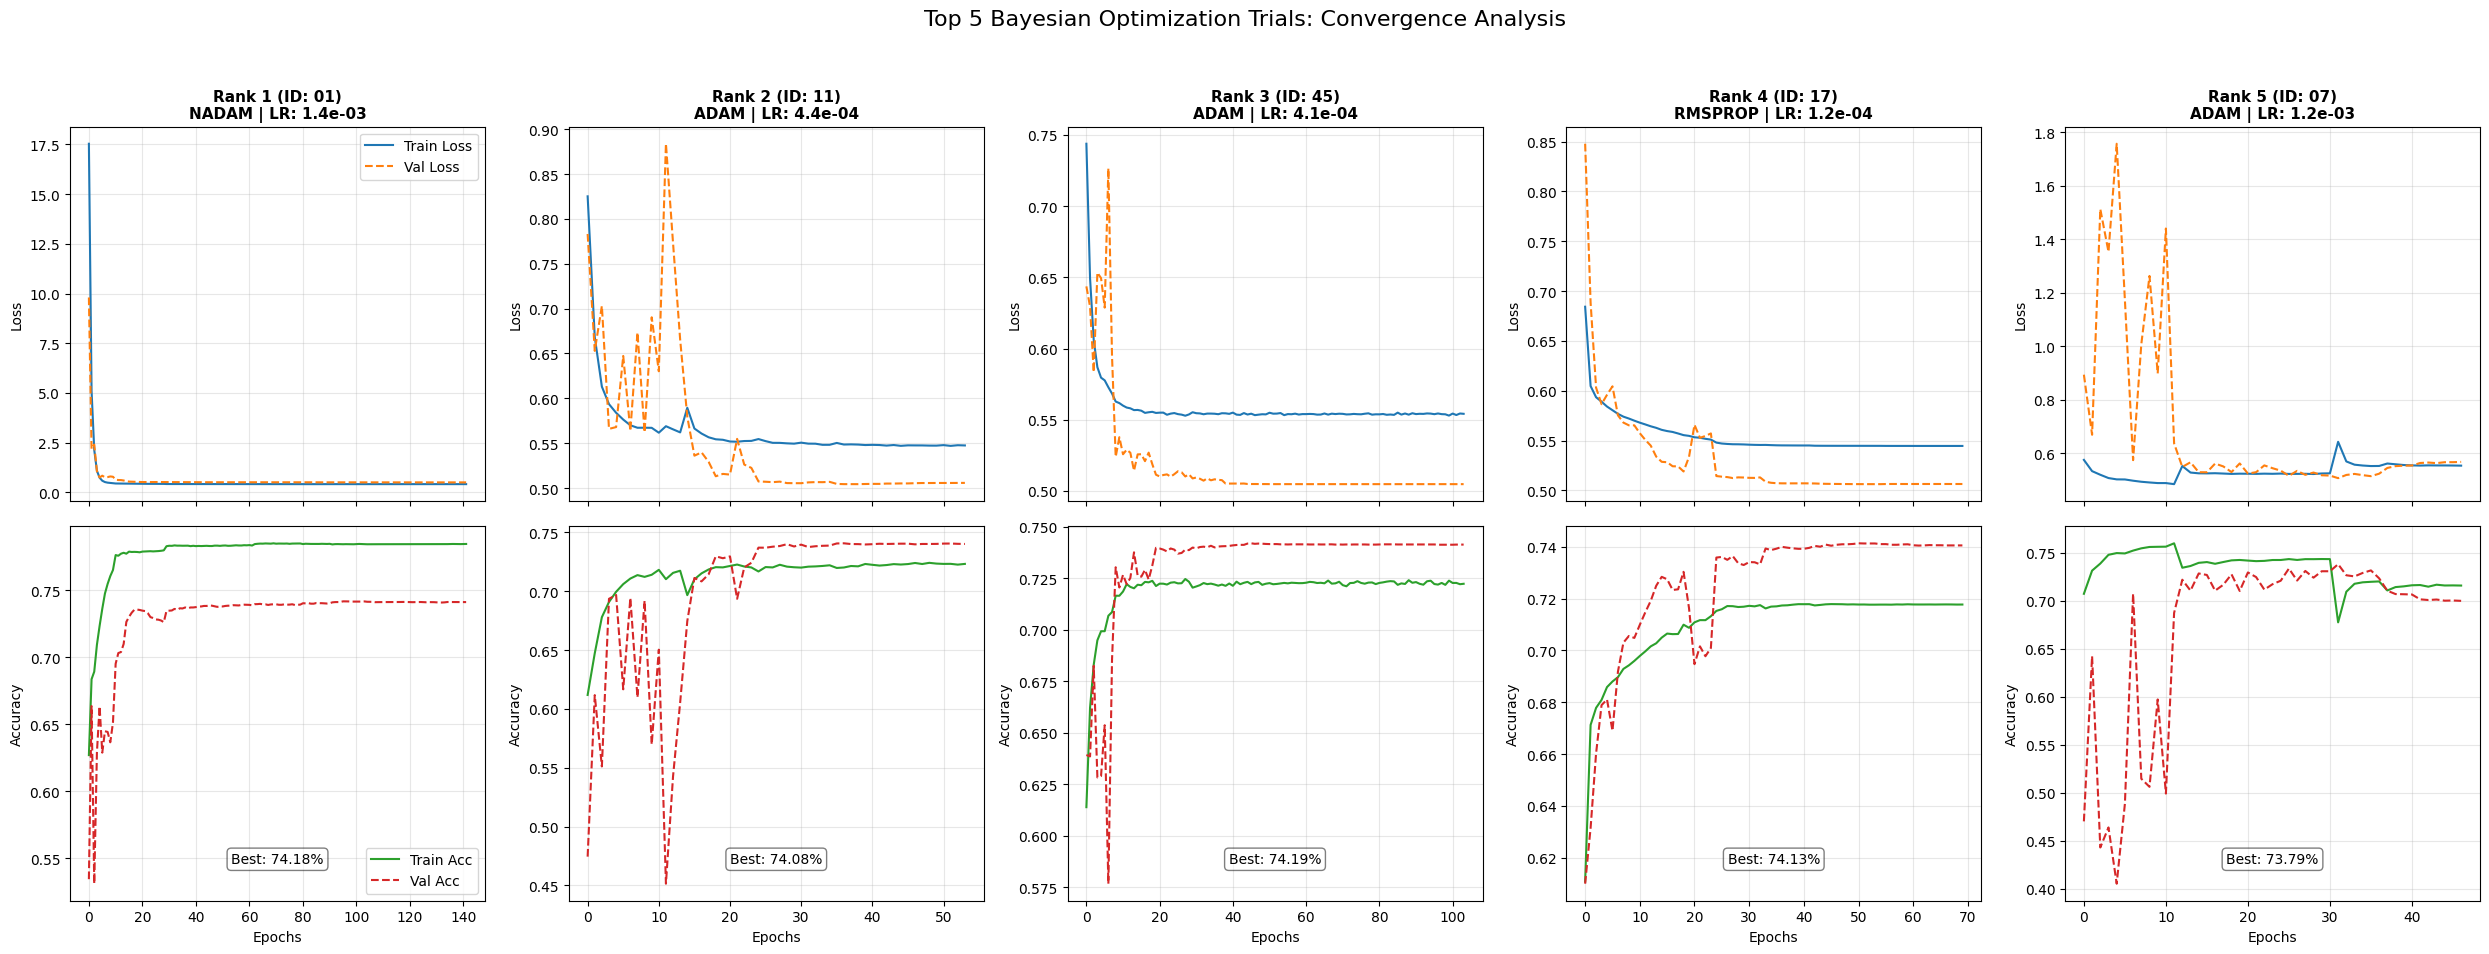

In [61]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Retrieve the top 5 trials based on the objective (val_loss)
top_n = 5
top_trials = tuner.oracle.get_best_trials(num_trials=top_n)

# 2. Setup the visualization grid (2 rows: Loss and Accuracy | 5 columns: Trials)
fig, axes = plt.subplots(2, top_n, figsize=(25, 10), sharex='col')
plt.subplots_adjust(hspace=0.3, wspace=0.3)

for i, trial in enumerate(top_trials):
    trial_id = trial.trial_id
    history_path = os.path.join('bayesian_tuning_v4', 'customer_seg_final', f"trial_{trial_id}", "trial_history.csv")
    
    if os.path.exists(history_path):
        history_df = pd.read_csv(history_path)
        hps = trial.hyperparameters.values
        
        # --- Row 1: Loss Plot ---
        ax_loss = axes[0, i]
        # Labeling Training and Validation explicitly
        ax_loss.plot(history_df['loss'], label='Train Loss', color='#1f77b4', linewidth=1.5)
        ax_loss.plot(history_df['val_loss'], label='Val Loss', color='#ff7f0e', linestyle='--', linewidth=1.5)
        
        ax_loss.set_title(f"Rank {i+1} (ID: {trial_id})\n{hps.get('optimizer_name').upper()} | LR: {hps.get('learning_rate'):.1e}", fontsize=11, fontweight='bold')
        ax_loss.set_ylabel('Loss')
        ax_loss.grid(True, alpha=0.3)
        if i == 0: ax_loss.legend() # Legend for the first column

        # --- Row 2: Accuracy Plot ---
        ax_acc = axes[1, i]
        # Added labels here so they can be identified in a legend
        ax_acc.plot(history_df['accuracy'], label='Train Acc', color='#2ca02c', linewidth=1.5)
        ax_acc.plot(history_df['val_accuracy'], label='Val Acc', color='#d62728', linestyle='--', linewidth=1.5)
        
        ax_acc.set_ylabel('Accuracy')
        ax_acc.set_xlabel('Epochs')
        
        # Annotate best validation accuracy
        best_val = history_df['val_accuracy'].max()
        ax_acc.annotate(f'Best: {best_val:.2%}', xy=(0.5, 0.1), xycoords='axes fraction', 
                        ha='center', fontsize=10, bbox=dict(boxstyle="round", fc="w", alpha=0.5))
        
        ax_acc.grid(True, alpha=0.3)
        if i == 0: ax_acc.legend() # Added legend to first column of Accuracy row
        

plt.suptitle(f"Top {top_n} Bayesian Optimization Trials: Convergence Analysis", fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [32]:
print("\nExtracting the best epoch from the CSV logs...")

# 1. Get the best trial object from the tuner
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial_id = best_trial.trial_id

# 2. Reconstruct the path to that specific trial's CSV file
best_trial_csv_path = os.path.join(
    tuner.directory, 
    tuner.project_name, 
    f"trial_{best_trial_id}", 
    "trial_history.csv"
)

# 3. Read the CSV using Pandas
history_df = pd.read_csv(best_trial_csv_path)

# 4. Find the row with the minimum validation loss
# Note: CSVLogger logs epochs starting at 0, so we add 1 for the actual step count
best_epoch_step = history_df.loc[history_df['val_loss'].idxmin(), 'epoch'] + 1

print(f"--> Best trial ID: {best_trial_id}")
print(f"--> Lowest validation loss achieved at epoch: {best_epoch_step}")



# Rebuild the best model architecture
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
final_model = tuner.hypermodel.build(best_hps)

# Combine train and validation data
X_final_train = np.concatenate((X_train_resampled, X_val), axis=0)
y_final_train = np.concatenate((y_train_resampled, y_val), axis=0)

# Apply the 20% heuristic for the larger dataset
optimal_epochs = int(best_epoch_step * 1.20)

# Set up the final dataset pipeline
BATCH_SIZE = best_hps.get('batch_size') if 'batch_size' in best_hps.values else 32
final_train_ds = (
    tf.data.Dataset.from_tensor_slices((X_final_train, y_final_train))
    .shuffle(len(X_final_train))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"\nRetraining the final model on the full combined dataset for {optimal_epochs} epochs...")

# Train without EarlyStopping so it hits the exact calculated target
final_history = final_model.fit(
    final_train_ds,
    epochs=optimal_epochs,  
    verbose=1
)

# Save the finalized model
final_model.save('final_customer_segmentation_model.keras')
print("\nModel retraining complete and saved to disk.")


Extracting the best epoch from the CSV logs...
--> Best trial ID: 01
--> Lowest validation loss achieved at epoch: 127

Retraining the final model on the full combined dataset for 152 epochs...
Epoch 1/152
2946/2946 [==============================] - 20s 5ms/step - loss: 12.5757 - accuracy: 0.6036
Epoch 2/152
2946/2946 [==============================] - 16s 5ms/step - loss: 4.0851 - accuracy: 0.6674
Epoch 3/152
2946/2946 [==============================] - 16s 5ms/step - loss: 2.1303 - accuracy: 0.6868
Epoch 4/152
2946/2946 [==============================] - 16s 5ms/step - loss: 1.2842 - accuracy: 0.7028
Epoch 5/152
2946/2946 [==============================] - 16s 5ms/step - loss: 0.8795 - accuracy: 0.7153
Epoch 6/152
2946/2946 [==============================] - 16s 5ms/step - loss: 0.6547 - accuracy: 0.7284
Epoch 7/152
2946/2946 [==============================] - 16s 5ms/step - loss: 0.5233 - accuracy: 0.7450
Epoch 8/152
2946/2946 [==============================] - 15s 5ms/step - loss

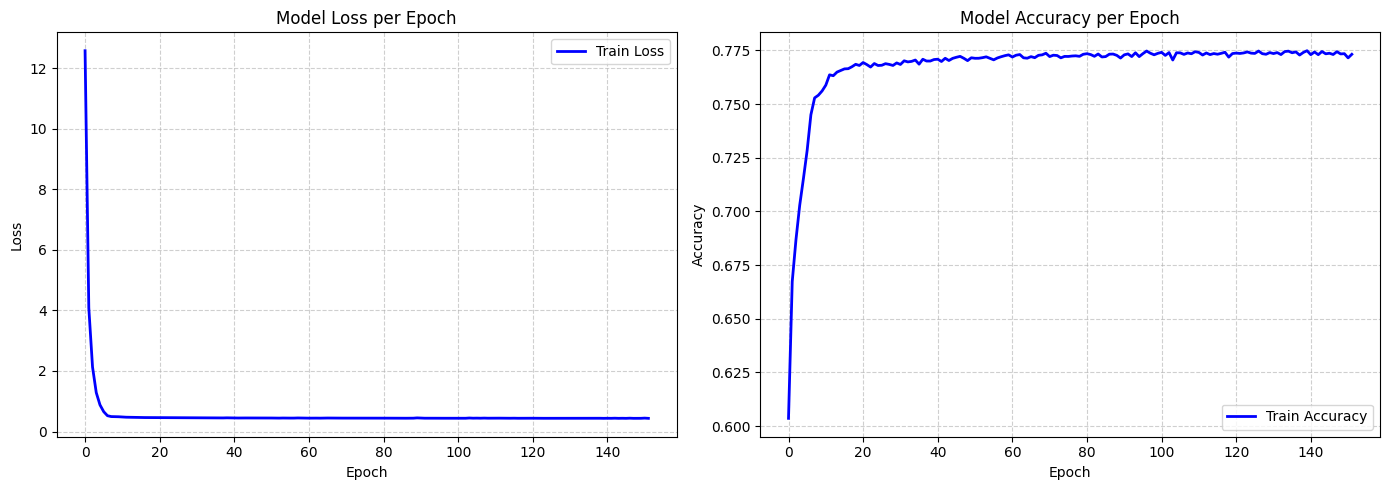

In [36]:
plot_training_history(final_history)

2446/2446 [==============================] - 3s 980us/step
Accuracy:  0.7856
Precision (Macro): 0.7859
Recall (Macro):    0.7856
F1-score (Macro):  0.7855



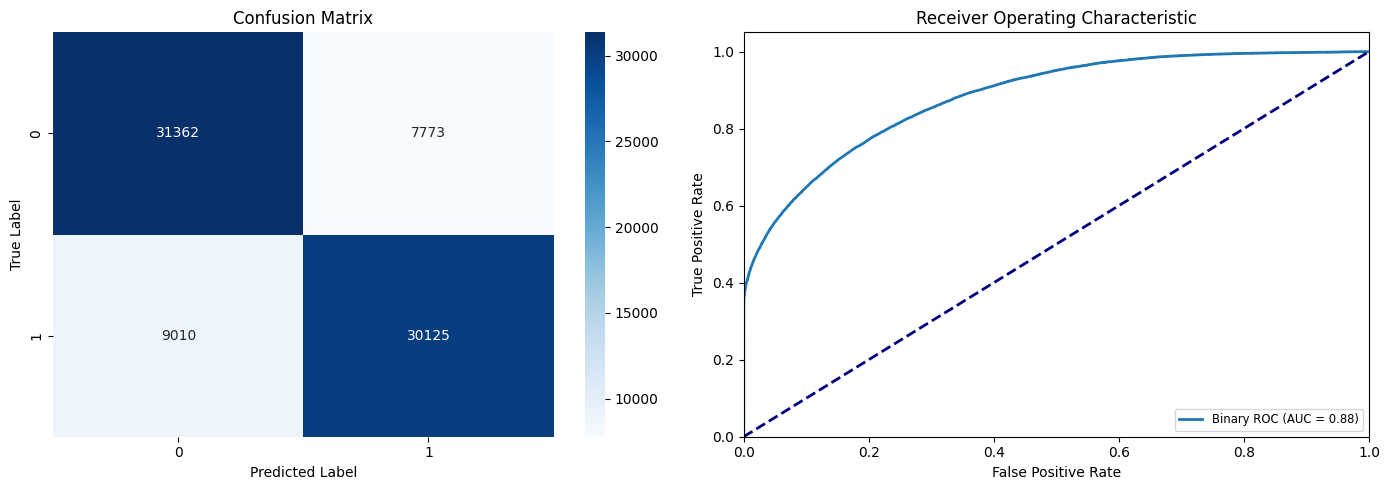

In [37]:
optimized_metrics = evaluate_multiclass_model(final_model, X_train_resampled, y_train_resampled, 2)

625/625 [==============================] - 1s 1ms/step
Accuracy:  0.7385
Precision (Macro): 0.7259
Recall (Macro):    0.7216
F1-score (Macro):  0.7234



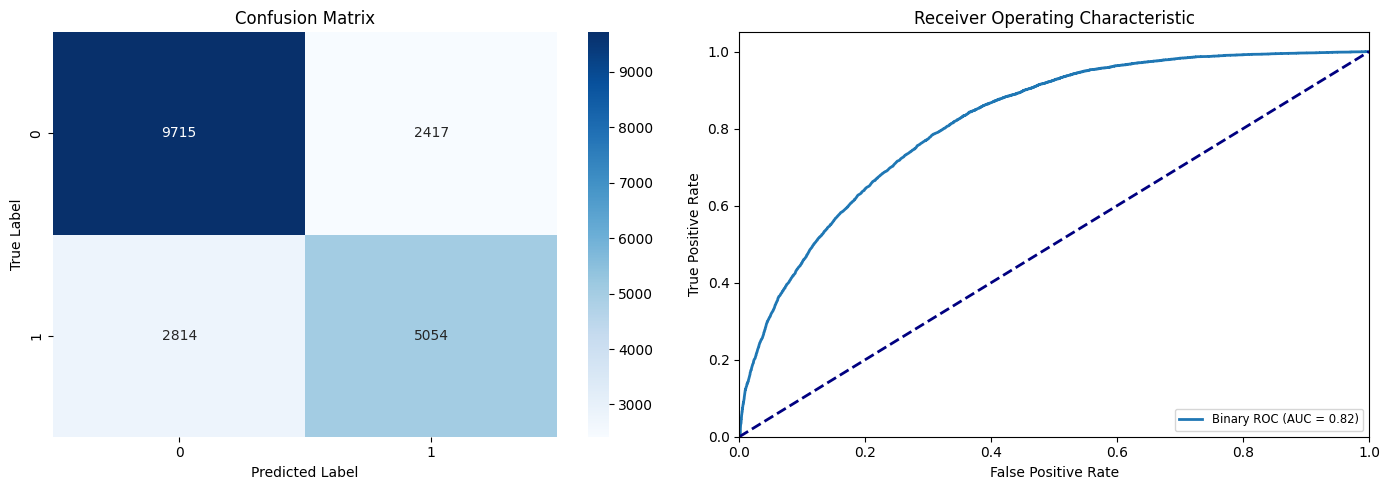

In [40]:
optimized_metrics = evaluate_multiclass_model(final_model, X_test, y_test, 2)

#### Saving Optimized Results

In [42]:
# Convert the comprehensive cross-validation results to a DataFrame
# cv_results_df = pd.DataFrame(search_result.cv_results_)

# Sort by rank to ensure the best performing models are at the top
# cv_results_df = cv_results_df.sort_values('rank_test_score')

# Save Training History to CSV
history_df = pd.DataFrame(final_history.history)
history_df.to_csv('baseline_training_history.csv', index_label='epoch')

# Save the results to a CSV file for reporting
# cv_results_df.to_csv('random_search_summary_results.csv', index=False)

# Save Training History to CSV
# history_df = pd.DataFrame(search_result.best_estimator_.history_)
# history_df.to_csv('baseline_training_history.csv', index_label='epoch')

# Save Evaluation Metrics to CSV
optimized_metrics.to_csv('baseline_model_metrics.csv', index=False)

#### Plotting Influence of Parameters on Results

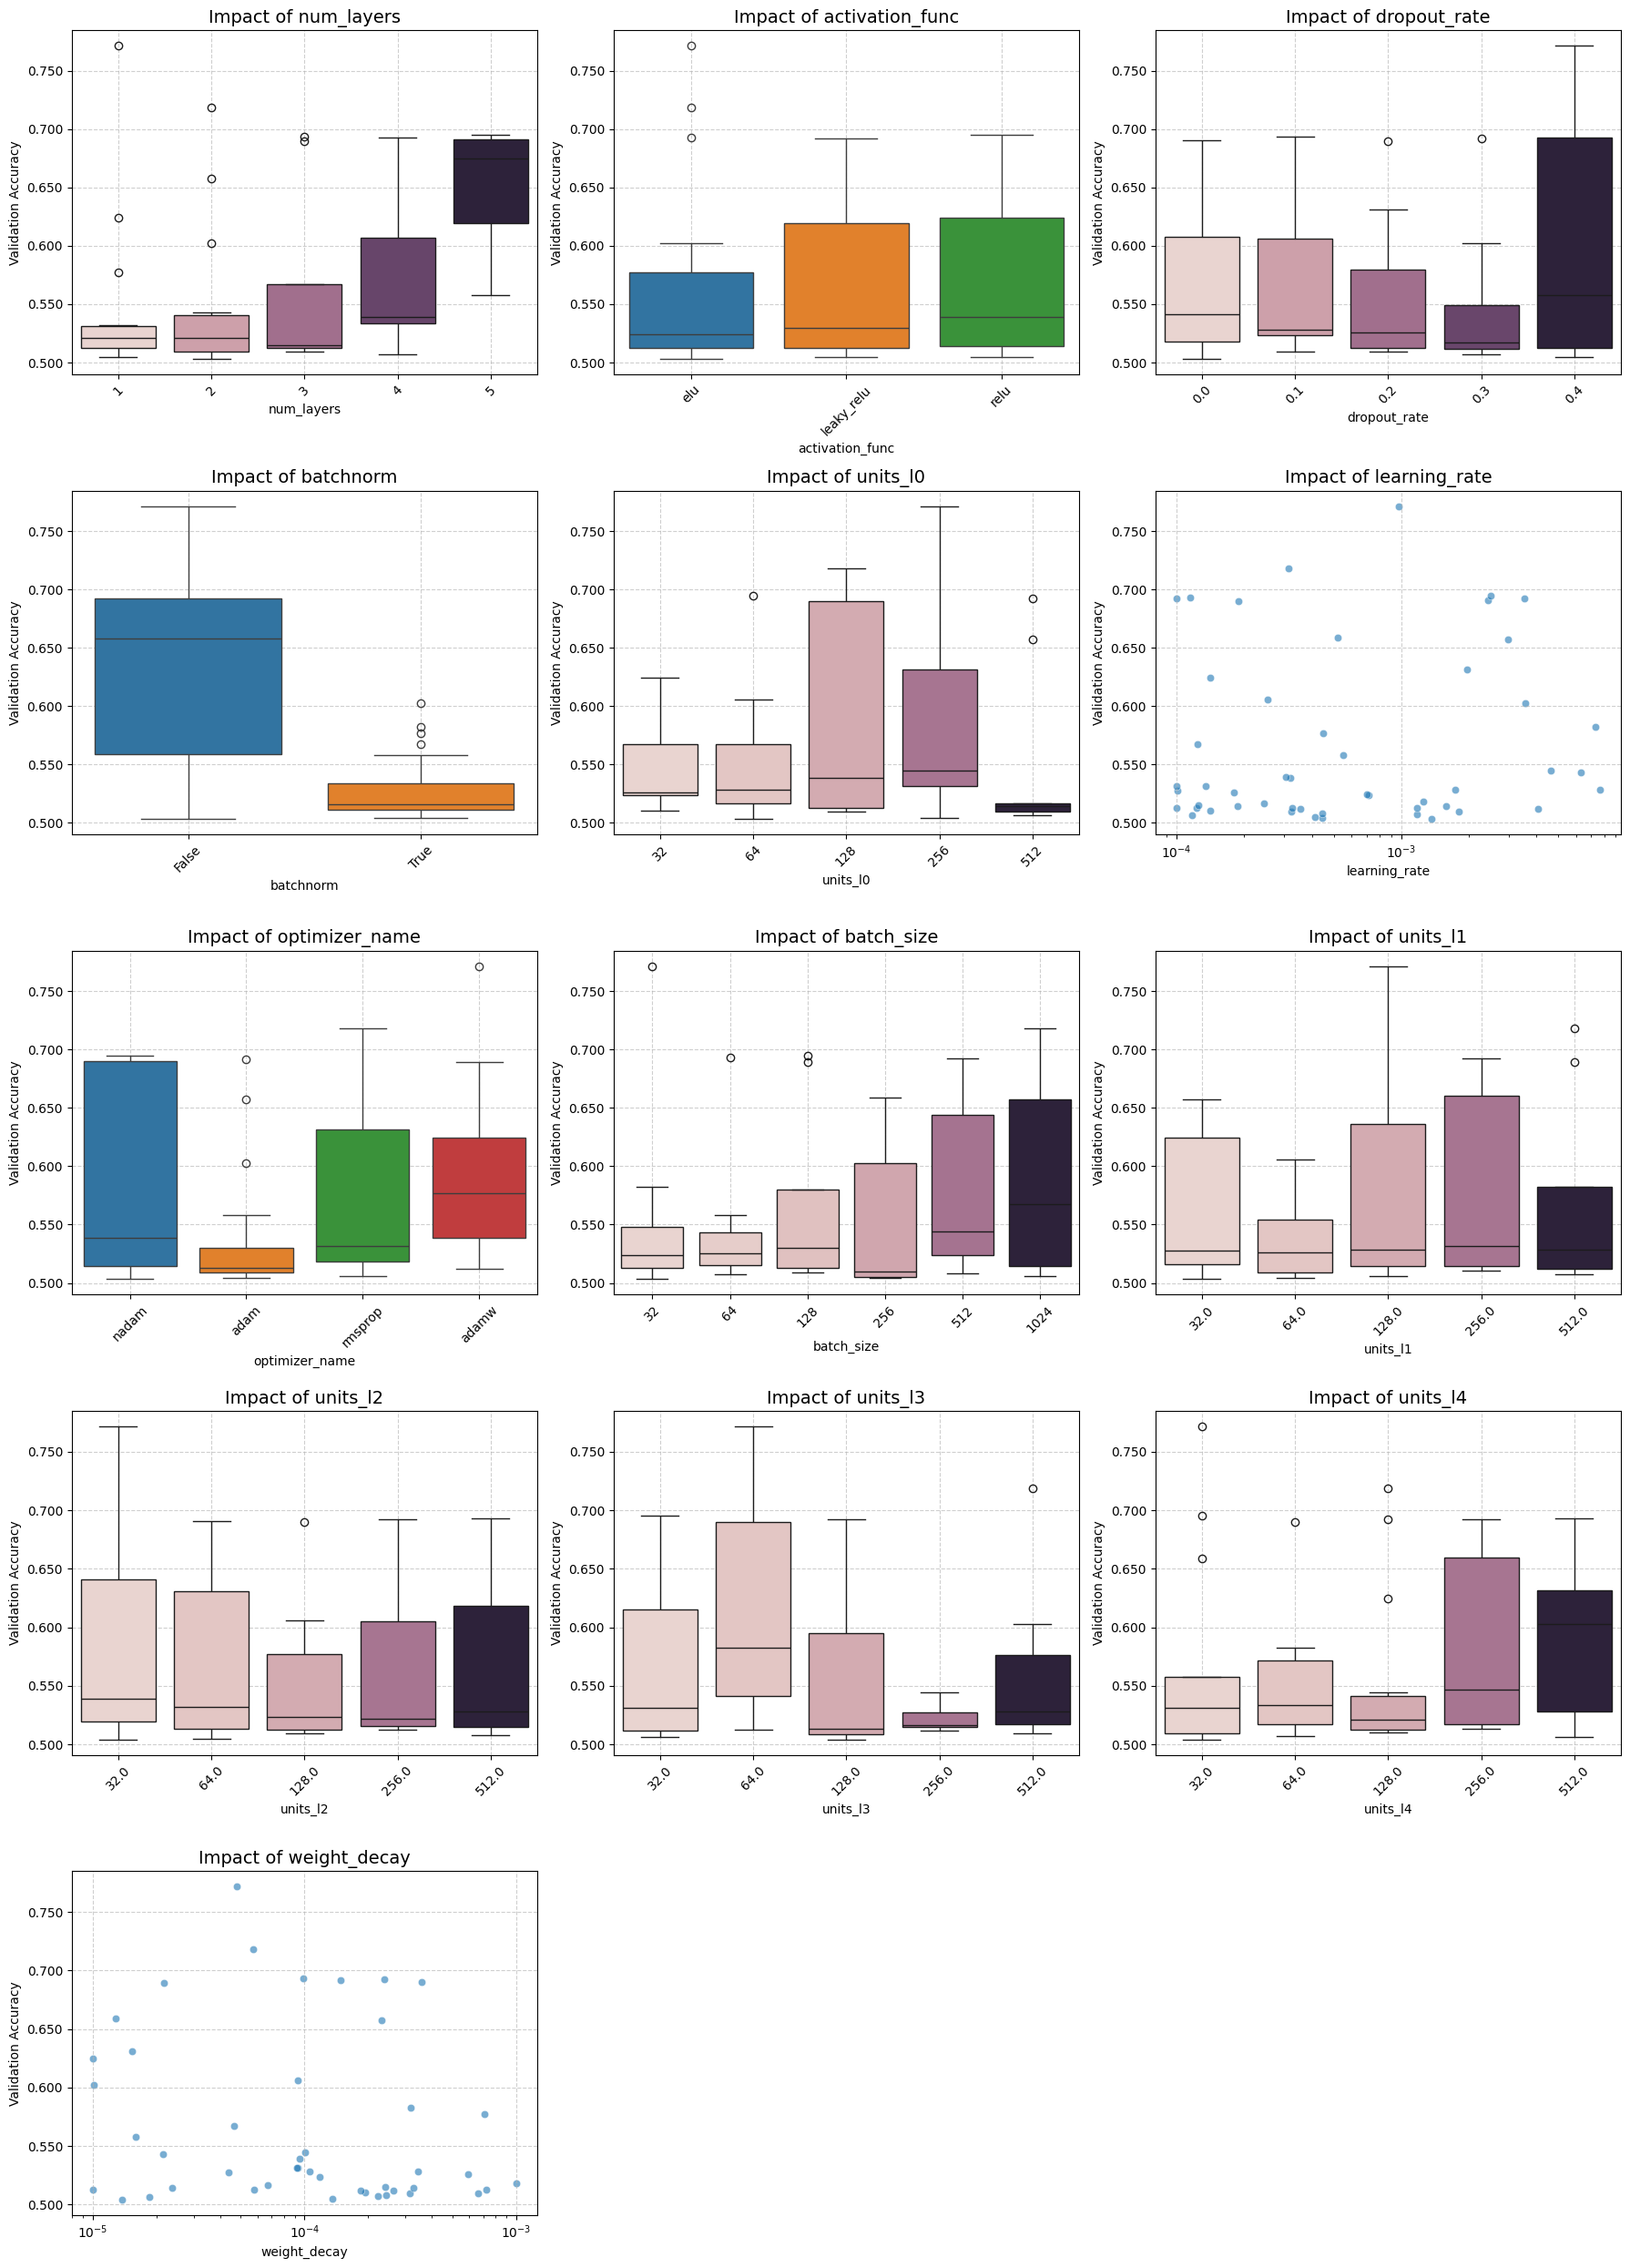

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

def plot_tuner_analysis_refined(tuner):
    # Extract trial results into a structured DataFrame
    trials = tuner.oracle.get_best_trials(num_trials=len(tuner.oracle.trials))
    data = []
    for trial in trials:
        trial_data = trial.hyperparameters.values.copy()
        trial_data['score'] = trial.score
        data.append(trial_data)
        
    results_df = pd.DataFrame(data)
    param_cols = [col for col in results_df.columns if col != 'score']

    num_params = len(param_cols)
    num_cols = 3
    num_rows = (num_params + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 5 * num_rows))
    axes = axes.flatten()

    for i, col in enumerate(param_cols):
        display_name = col.replace('model__', '')
        
        # Enforce 3 decimal places on the Y-axis (Validation Accuracy)
        axes[i].yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))

        if col in ['weight_decay', 'learning_rate']:
            sns.scatterplot(x=col, y='score', data=results_df, ax=axes[i], alpha=0.6)
            axes[i].set_xscale('log')
            # For log scales, scientific notation is maintained for readability
        else:
            # Round continuous numeric values to 3 decimals for clean categorical labels
            plot_df = results_df.copy()
            if plot_df[col].dtype in [np.float64, np.float32]:
                plot_df[col] = plot_df[col].round(3)

            sns.boxplot(x=col, y='score', data=plot_df, ax=axes[i], hue=col, legend=False)
            axes[i].tick_params(axis='x', rotation=45)

        axes[i].set_title(f'Impact of {display_name}', fontsize=14)
        axes[i].set_xlabel(display_name)
        axes[i].set_ylabel('Validation Accuracy')
        axes[i].grid(True, linestyle='--', alpha=0.6)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Execute the visualization
plot_tuner_analysis_refined(tuner)

# End of Baseline and Optimization of ANN